# Whitmore Hybrid TAA Results Dashboard

This notebook is bound to `Whitmore_IPS_extracted.txt` and the rerun autoresearch artifacts in `backtesting/artifacts/`.

Hard IPS targets used in every chart:
- Return p.a. `>= 8%`
- Volatility p.a. `<= 15%`
- Max drawdown `>= -25%`

Benchmark handling:
- Benchmark 1 is the Whitmore 60/40 portfolio.
- Benchmark 2 is the Whitmore diversified policy portfolio.
- Local `data/` does **not** contain Japan equity, China A-shares, silver, or Swiss franc price history, so Benchmark 2 is computed from the available local components and renormalized to 100%.
- JPY is not used anywhere in the rerun portfolio universe because the IPS specifies Swiss franc, not JPY, and no local CHF series exists to trade.

In [1]:
%matplotlib inline
import json
import sys
import warnings
from pathlib import Path

# Resolve repo root for imports and for paths below. Cwd may be the repo root
# or `.../backtesting/` (e.g. notebook opened from that folder).
_root = Path.cwd().resolve()
if not (_root / "backtesting" / "__init__.py").is_file():
    _root = _root.parent
if (_root / "backtesting" / "__init__.py").is_file():
    sys.path.insert(0, str(_root))
ROOT = _root

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

from backtesting.core.backtest import compute_metrics, feasible_returns, run_benchmark_backtest, run_saa_backtest
from backtesting.core.data import load_market_panel
from backtesting.core.ips import (
    ASSET_ORDER,
    BENCHMARK_1_WEIGHTS,
    BENCHMARK_2_WEIGHTS,
    BENCHMARK_PROXY_NOTES,
    IPS_MAX_DRAWDOWN_TARGET,
    IPS_RETURN_TARGET,
    IPS_VOL_TARGET,
    available_benchmark_weights,
)
from backtesting.prepare import make_folds, prepare_dataset

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)
plt.style.use("seaborn-v0_8-whitegrid")

ARTIFACTS = ROOT / "backtesting" / "artifacts"
SEARCH_CSV = ARTIFACTS / "search_results.csv"
RESULTS_TSV = ROOT / "backtesting" / "results.tsv"

search = pd.read_csv(SEARCH_CSV).sort_values("ips_objective", na_position="last").reset_index(drop=True)

summary_rows = []
for path in sorted(ARTIFACTS.glob("h*_xgb_*_*/summary.json")):
    payload = json.loads(path.read_text())
    summary_rows.append({
        "artifact_dir": path.parent,
        "hypothesis": payload["hypothesis"],
        "model": payload["model"],
        "active_assets": ", ".join(payload["active_assets"]),
        "ips_pass": payload["ips_pass_count_taa"],
        "ips_objective": payload["ips_objective_taa"],
        "return_pa": payload["taa_metrics"]["total_return_pa"],
        "vol_pa": payload["taa_metrics"]["volatility_pa"],
        "max_dd": payload["taa_metrics"]["max_drawdown"],
        "sharpe": payload["taa_metrics"]["sharpe_rf2"],
        "calmar": payload["taa_metrics"]["calmar"],
        "n_signals": payload["n_signals_fired"],
    })
summary = pd.DataFrame(summary_rows).sort_values("ips_objective").reset_index(drop=True)
if summary.empty:
    raise RuntimeError("No rerun artifacts were found in backtesting/artifacts.")

best_artifact = summary.iloc[0].copy()

readable_summary = summary[["hypothesis", "model", "ips_pass", "ips_objective", "return_pa", "vol_pa", "max_dd", "sharpe", "calmar", "n_signals", "active_assets"]].copy()
for col in ["return_pa", "vol_pa", "max_dd"]:
    readable_summary[col] = readable_summary[col].map(lambda x: f"{x:.2%}")
readable_summary["ips_objective"] = readable_summary["ips_objective"].map(lambda x: f"{x:.3f}")
readable_summary["sharpe"] = readable_summary["sharpe"].map(lambda x: f"{x:.3f}")
readable_summary["calmar"] = readable_summary["calmar"].map(lambda x: f"{x:.3f}")

display(Markdown(f"**Best saved artifact:** `{best_artifact['hypothesis']}/{best_artifact['model']}` in `{best_artifact['artifact_dir']}`"))
display(readable_summary)


**Best saved artifact:** `h1/xgb_lstm` in `/Users/kavinravi/Documents/FIN_496/foundation_project/backtesting/artifacts/h1_xgb_lstm_83955db5`

,hypothesis,model,ips_pass,ips_objective,return_pa,vol_pa,max_dd,sharpe,calmar,n_signals,active_assets
0,h1,xgb_lstm,3,18.698,9.49%,9.13%,-19.05%,0.820,0.498,61,"US Equity, US Treasuries, US TIPS, US REITs, G..."
1,h1,xgb_transformer,2,1029.136,9.19%,10.03%,-26.65%,0.728,0.345,53,"US Equity, US Treasuries, US TIPS, US REITs, G..."
2,h3,xgb_transformer,2,1034.084,9.17%,10.29%,-28.98%,0.711,0.316,49,"US Equity, US Treasuries, US TIPS, US REITs, G..."
3,h3,xgb_lstm,2,1037.096,8.35%,10.20%,-30.12%,0.642,0.277,49,"US Equity, US Treasuries, US TIPS, US REITs, G..."
4,h4,xgb_transformer,2,1037.486,8.84%,10.23%,-30.55%,0.685,0.289,11,"US Equity, US Treasuries, US TIPS, US REITs, G..."
5,h4,xgb_lstm,2,1037.504,8.86%,10.26%,-30.55%,0.685,0.290,11,"US Equity, US Treasuries, US TIPS, US REITs, G..."
6,h2,xgb_transformer,2,1038.575,9.46%,11.14%,-30.94%,0.688,0.306,47,"US Equity, US Treasuries, US TIPS, US REITs, G..."
7,h2,xgb_lstm,2,1038.718,9.46%,11.29%,-30.94%,0.681,0.306,47,"US Equity, US Treasuries, US TIPS, US REITs, G..."


In [2]:
# Build same-window benchmarks and SAA for the best saved TAA artifact.
best_dir = Path(best_artifact["artifact_dir"])
taa_returns = pd.read_csv(best_dir / "taa_daily_returns.csv", parse_dates=["date"], index_col="date")["return"]
taa_returns.name = f"Best TAA ({best_artifact['hypothesis']}/{best_artifact['model']})"

panel = load_market_panel().slice(end=pd.Timestamp("2026-04-15"))
returns_full = feasible_returns(panel.returns, asset_universe=ASSET_ORDER).loc[:taa_returns.index.max()]
run_start = taa_returns.index.min()

saa = run_saa_backtest(returns_full, asset_universe=ASSET_ORDER, strategy_name="SAA", run_start=run_start)
bm1 = run_benchmark_backtest(
    returns_full,
    asset_universe=ASSET_ORDER,
    benchmark_weights=BENCHMARK_1_WEIGHTS,
    strategy_name="Benchmark 1 60/40",
    run_start=run_start,
)
bm2 = run_benchmark_backtest(
    returns_full,
    asset_universe=ASSET_ORDER,
    benchmark_weights=BENCHMARK_2_WEIGHTS,
    strategy_name="Benchmark 2 Diversified Policy",
    run_start=run_start,
)

all_returns = pd.concat([
    bm1.daily_returns.rename("Benchmark 1 60/40"),
    bm2.daily_returns.rename("Benchmark 2 Diversified Policy"),
    saa.daily_returns.rename("SAA"),
    taa_returns,
], axis=1).dropna(how="any")

metrics = pd.DataFrame({name: compute_metrics(all_returns[name]) for name in all_returns.columns}).T
metrics.insert(0, "ips_pass", [
    f"{int(row.total_return_pa >= IPS_RETURN_TARGET) + int(row.volatility_pa <= IPS_VOL_TARGET) + int(row.max_drawdown >= IPS_MAX_DRAWDOWN_TARGET)}/3"
    for row in metrics.itertuples()
])

benchmark_weights = pd.DataFrame({
    "Benchmark 1 available": available_benchmark_weights(BENCHMARK_1_WEIGHTS, list(returns_full.columns)),
    "Benchmark 2 available": available_benchmark_weights(BENCHMARK_2_WEIGHTS, list(returns_full.columns)),
}).fillna(0.0)

display(Markdown("**Benchmark weights used in the rerun**"))
display(benchmark_weights.style.format("{:.2%}"))
display(Markdown("**Same-window metrics for both benchmarks, SAA, and best TAA**"))
display(metrics.style.format({
    "total_return_pa": "{:.2%}",
    "volatility_pa": "{:.2%}",
    "max_drawdown": "{:.2%}",
    "historical_var_95_daily": "{:.2%}",
    "sharpe_rf2": "{:.3f}",
    "calmar": "{:.3f}",
}))
display(Markdown("**Benchmark 2 availability note:** " + " ".join(f"{k}: {v}" for k, v in BENCHMARK_PROXY_NOTES.items())))


**Benchmark weights used in the rerun**

,Benchmark 1 available,Benchmark 2 available
Gold,0.00%,18.75%
US Equity,60.00%,50.00%
US REITs,0.00%,12.50%
US TIPS,0.00%,6.25%
US Treasuries,40.00%,12.50%


**Same-window metrics for both benchmarks, SAA, and best TAA**

,ips_pass,total_return_pa,cumulative_return,volatility_pa,historical_var_95_daily,sharpe_rf2,calmar,max_drawdown
Benchmark 1 60/40,1/3,6.50%,3.171311,10.54%,-0.93%,0.462,0.197,-32.93%
Benchmark 2 Diversified Policy,1/3,7.71%,4.382456,11.91%,-1.03%,0.516,0.219,-35.24%
SAA,2/3,8.50%,5.351058,10.41%,-0.93%,0.645,0.278,-30.54%
Best TAA (h1/xgb_lstm),3/3,9.49%,6.810608,9.13%,-0.85%,0.820,0.498,-19.05%


**Benchmark 2 availability note:** US TIPS: BROAD_TIPS is unavailable; using local 0_5Y_TIPS_2002_D as the TIPS proxy. Japan Equity: Unavailable in local data; dropped from computable Benchmark 2 weights. China A-Shares: Unavailable in local data; dropped from computable Benchmark 2 weights. Silver: Unavailable in local data; dropped from computable Benchmark 2 weights. Swiss Franc: Unavailable in local data; dropped from computable Benchmark 2 weights.

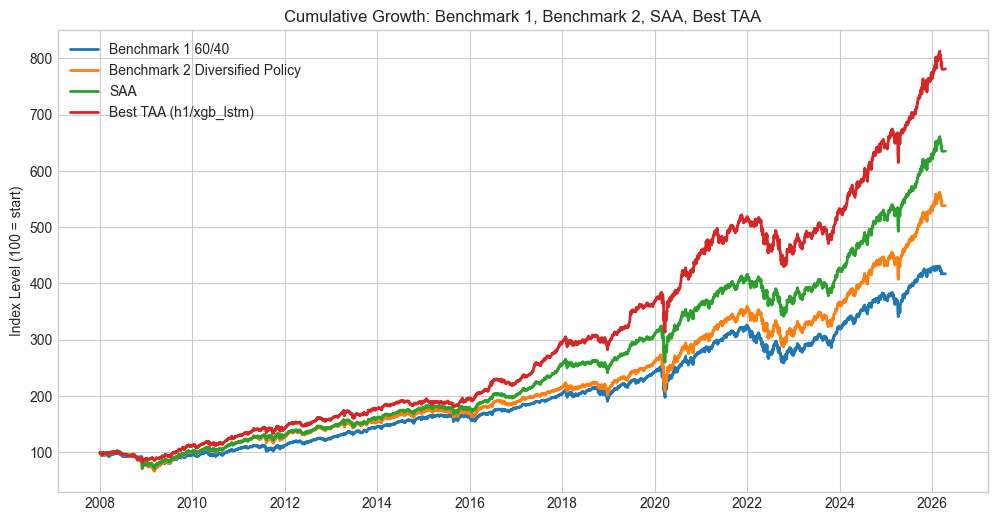

In [3]:
# Cumulative growth of the two benchmarks, SAA, and best TAA.
growth = (1.0 + all_returns).cumprod() * 100.0
fig, ax = plt.subplots(figsize=(12, 6))
for col in growth.columns:
    ax.plot(growth.index, growth[col], linewidth=2, label=col)
ax.set_title("Cumulative Growth: Benchmark 1, Benchmark 2, SAA, Best TAA")
ax.set_ylabel("Index Level (100 = start)")
ax.legend(loc="upper left")
plt.show()


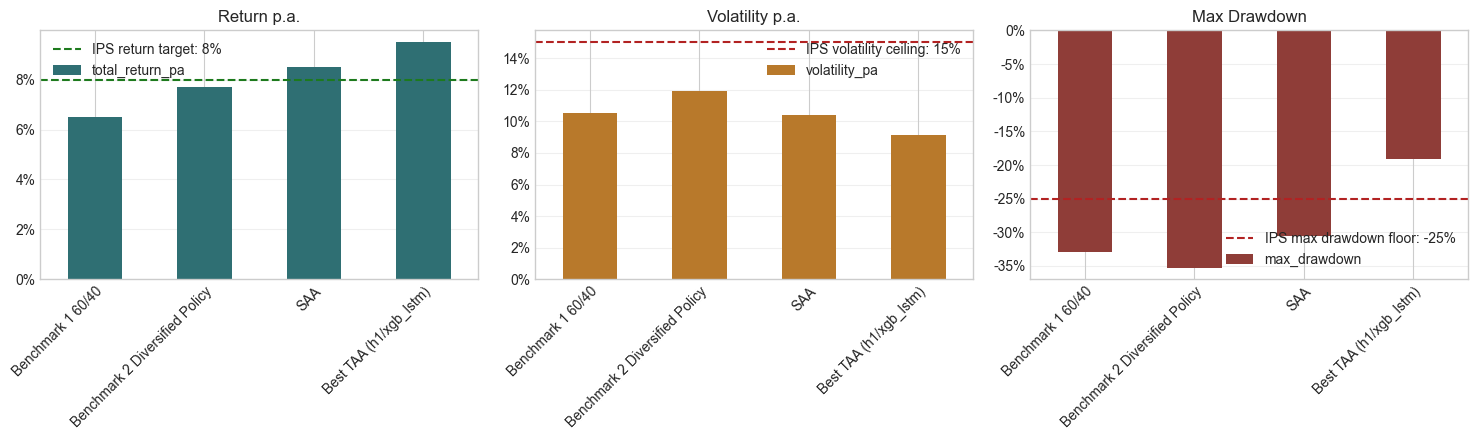

In [4]:
# IPS target bars for the four required portfolios.
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
plot_metrics = metrics[["total_return_pa", "volatility_pa", "max_drawdown"]].copy()

plot_metrics["total_return_pa"].plot(kind="bar", ax=axes[0], color="#2f6f73")
axes[0].axhline(IPS_RETURN_TARGET, color="#1d7a1d", linestyle="--", linewidth=1.5, label="IPS return target: 8%")
axes[0].set_title("Return p.a.")
axes[0].yaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
axes[0].legend(loc="best")

plot_metrics["volatility_pa"].plot(kind="bar", ax=axes[1], color="#b8792b")
axes[1].axhline(IPS_VOL_TARGET, color="#b22222", linestyle="--", linewidth=1.5, label="IPS volatility ceiling: 15%")
axes[1].set_title("Volatility p.a.")
axes[1].yaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
axes[1].legend(loc="best")

plot_metrics["max_drawdown"].plot(kind="bar", ax=axes[2], color="#8f3d38")
axes[2].axhline(IPS_MAX_DRAWDOWN_TARGET, color="#b22222", linestyle="--", linewidth=1.5, label="IPS max drawdown floor: -25%")
axes[2].set_title("Max Drawdown")
axes[2].yaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
axes[2].legend(loc="best")

for ax in axes:
    plt.setp(
        ax.get_xticklabels(),
        rotation=45,
        ha="right",
        rotation_mode="anchor",
    )
    ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


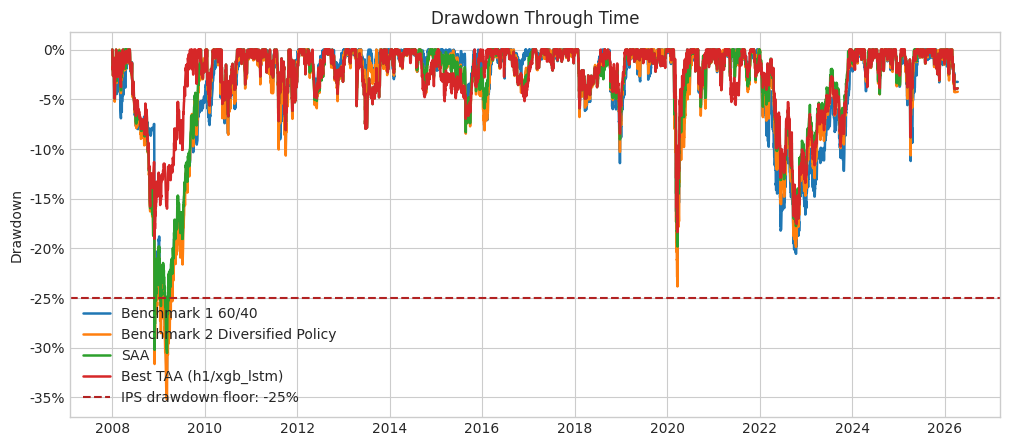

In [5]:
# Drawdown chart for both benchmarks, SAA, and best TAA.
drawdowns = growth.divide(growth.cummax()).subtract(1.0)
fig, ax = plt.subplots(figsize=(12, 5))
for col in drawdowns.columns:
    ax.plot(drawdowns.index, drawdowns[col], linewidth=1.8, label=col)
ax.axhline(IPS_MAX_DRAWDOWN_TARGET, color="#b22222", linestyle="--", linewidth=1.5, label="IPS drawdown floor: -25%")
ax.set_title("Drawdown Through Time")
ax.set_ylabel("Drawdown")
ax.yaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
ax.legend(loc="lower left")
plt.show()


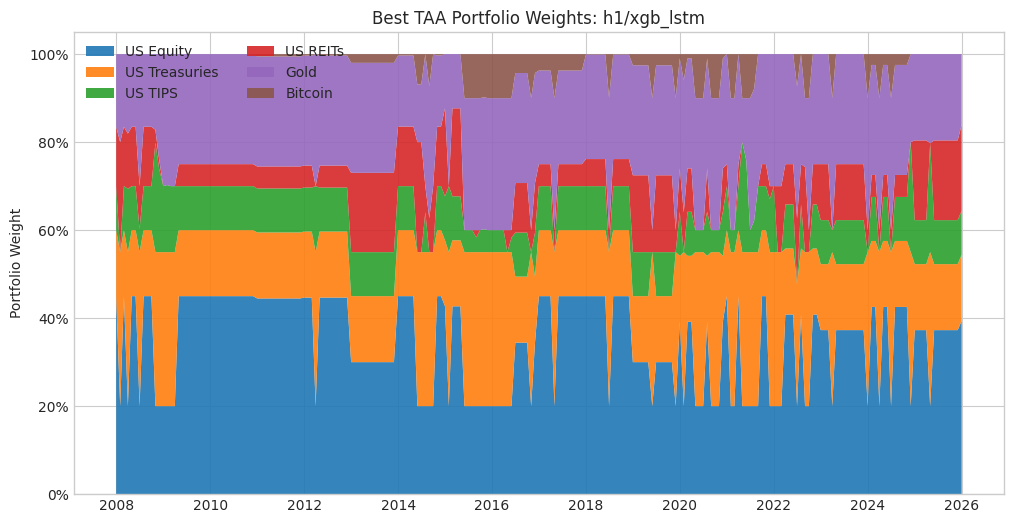

,min,mean,max,last
US Equity,20.00%,34.97%,45.00%,39.39%
Gold,10.00%,24.38%,30.00%,16.04%
US Treasuries,15.00%,20.59%,35.00%,15.00%
US TIPS,0.00%,9.10%,25.00%,10.00%
US REITs,0.00%,8.47%,25.00%,19.58%
Bitcoin,0.00%,2.49%,10.00%,0.00%


In [6]:
# Asset weights for the selected TAA portfolio.
weights = pd.read_csv(best_dir / "taa_weights.csv", parse_dates=["rebalance_date"], index_col="rebalance_date")
weights = weights.reindex(columns=ASSET_ORDER).fillna(0.0)

fig, ax = plt.subplots(figsize=(12, 6))
ax.stackplot(weights.index, [weights[col] for col in weights.columns], labels=weights.columns, alpha=0.9)
ax.set_title(f"Best TAA Portfolio Weights: {best_artifact['hypothesis']}/{best_artifact['model']}")
ax.set_ylabel("Portfolio Weight")
ax.yaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
ax.legend(loc="upper left", ncol=2)
plt.show()

weight_summary = pd.DataFrame({
    "min": weights.min(),
    "mean": weights.mean(),
    "max": weights.max(),
    "last": weights.iloc[-1],
}).sort_values("mean", ascending=False)
display(weight_summary.style.format("{:.2%}"))


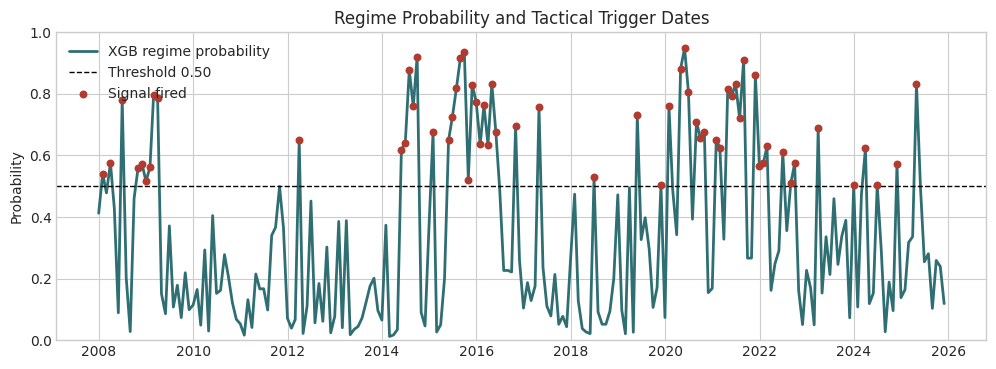

In [7]:
# Regime probability and trigger chart for the selected run.
proba = pd.read_csv(best_dir / "xgb_probability.csv", parse_dates=["date"], index_col="date")["probability"]
signal = pd.read_csv(best_dir / "signal.csv", parse_dates=["date"], index_col="date")["signal"]
selected_trial = search.loc[
    (search["hypothesis"] == best_artifact["hypothesis"])
    & (search["model"] == best_artifact["model"])
    & (search["ips_objective"] == search.loc[(search["hypothesis"] == best_artifact["hypothesis"]) & (search["model"] == best_artifact["model"]), "ips_objective"].min())
].iloc[0]
threshold = float(selected_trial["threshold"])

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(proba.index, proba, linewidth=2, color="#2f6f73", label="XGB regime probability")
ax.axhline(threshold, color="black", linestyle="--", linewidth=1, label=f"Threshold {threshold:.2f}")
active = signal[signal != 0]
ax.scatter(active.index, proba.reindex(active.index), color="#b23a2e", s=22, label="Signal fired", zorder=3)
ax.set_title("Regime Probability and Tactical Trigger Dates")
ax.set_ylabel("Probability")
ax.set_ylim(0, 1)
ax.legend(loc="upper left")
plt.show()


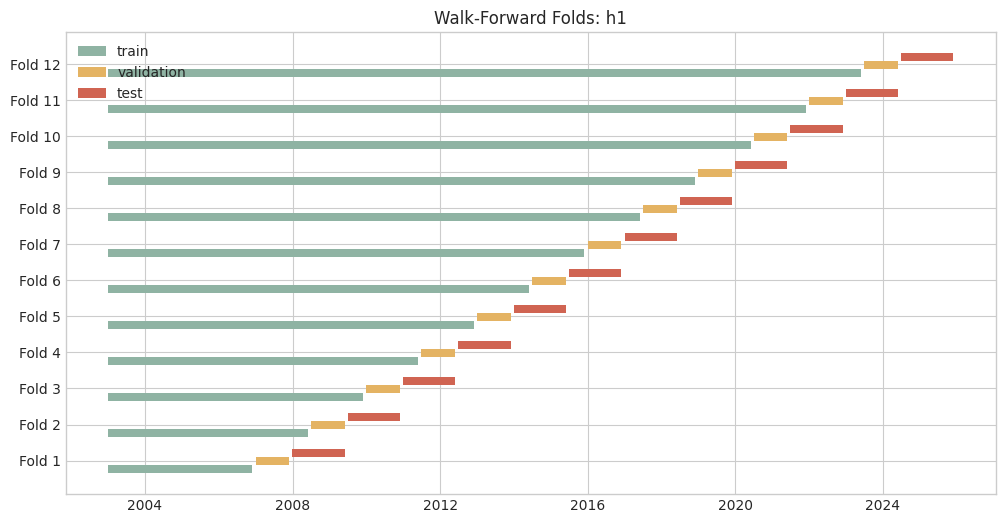

In [8]:
# Walk-forward fold structure for the selected hypothesis.
_, X, _ = prepare_dataset(str(best_artifact["hypothesis"]), panel=panel)
folds = make_folds(pd.DatetimeIndex(X.index))
fig, ax = plt.subplots(figsize=(12, 6))
colors = {"train": "#8fb3a3", "validation": "#e4b363", "test": "#d06452"}
for i, fold in enumerate(folds, start=1):
    y0 = i - 0.35
    for label, idx in [("train", fold.train), ("validation", fold.validation), ("test", fold.test)]:
        if len(idx) == 0:
            continue
        start = mdates.date2num(pd.Timestamp(idx.min()))
        end = mdates.date2num(pd.Timestamp(idx.max()))
        ax.broken_barh([(start, max(end - start, 10))], (y0, 0.22), facecolors=colors[label], label=label if i == 1 else None)
        y0 += 0.22
ax.set_title(f"Walk-Forward Folds: {best_artifact['hypothesis']}")
ax.set_yticks(range(1, len(folds) + 1))
ax.set_yticklabels([f"Fold {i}" for i in range(1, len(folds) + 1)])
ax.xaxis_date()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.legend(loc="upper left")
plt.show()


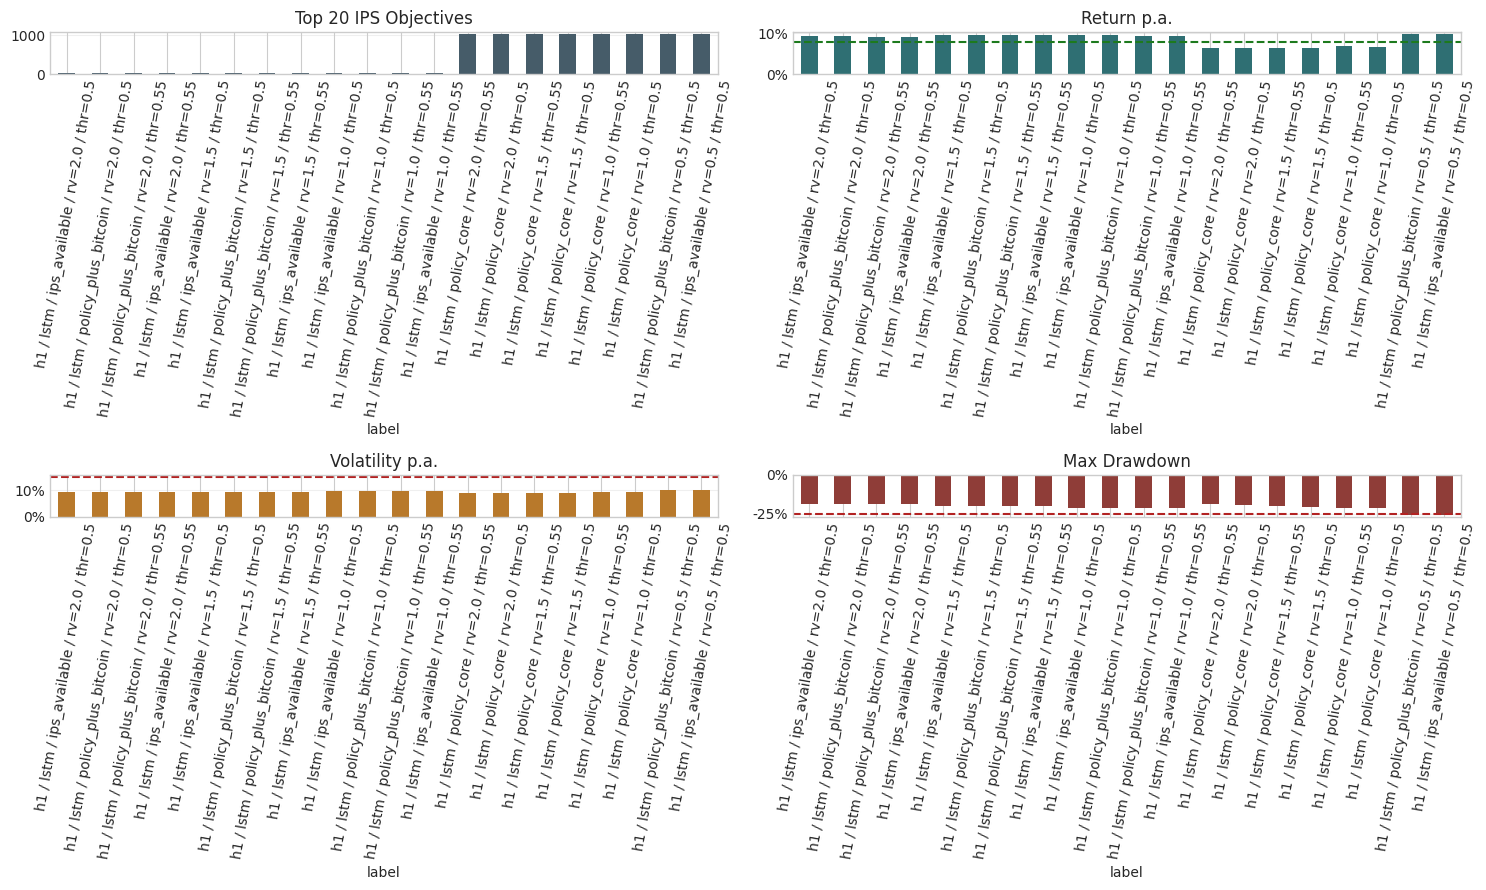

In [9]:
# Cross-trial bars: all rerun search rows, sorted by IPS objective.
plot_df = search.copy()
plot_df["label"] = (
    plot_df["hypothesis"].astype(str)
    + " / "
    + plot_df["model"].str.replace("xgb_", "", regex=False)
    + " / "
    + plot_df["asset_setup"].astype(str)
    + " / rv="
    + plot_df["regime_view_scale"].astype(str)
    + " / thr="
    + plot_df["threshold"].astype(str)
)
plot_df = plot_df.sort_values("ips_objective").head(20)

fig, axes = plt.subplots(2, 2, figsize=(15, 9))
plot_df.plot.bar(x="label", y="ips_objective", ax=axes[0, 0], legend=False, color="#465c69")
axes[0, 0].set_title("Top 20 IPS Objectives")

plot_df.plot.bar(x="label", y="return_pa", ax=axes[0, 1], legend=False, color="#2f6f73")
axes[0, 1].axhline(IPS_RETURN_TARGET, color="#1d7a1d", linestyle="--", linewidth=1.5)
axes[0, 1].set_title("Return p.a.")
axes[0, 1].yaxis.set_major_formatter(lambda x, _: f"{x:.0%}")

plot_df.plot.bar(x="label", y="vol_pa", ax=axes[1, 0], legend=False, color="#b8792b")
axes[1, 0].axhline(IPS_VOL_TARGET, color="#b22222", linestyle="--", linewidth=1.5)
axes[1, 0].set_title("Volatility p.a.")
axes[1, 0].yaxis.set_major_formatter(lambda x, _: f"{x:.0%}")

plot_df.plot.bar(x="label", y="max_dd", ax=axes[1, 1], legend=False, color="#8f3d38")
axes[1, 1].axhline(IPS_MAX_DRAWDOWN_TARGET, color="#b22222", linestyle="--", linewidth=1.5)
axes[1, 1].set_title("Max Drawdown")
axes[1, 1].yaxis.set_major_formatter(lambda x, _: f"{x:.0%}")

for ax in axes.flat:
    plt.setp(
        ax.get_xticklabels(),
        rotation=80,
        ha="right",
        rotation_mode="anchor",
    )
    ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()
